**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

**Load Data**

In [ ]:
loan = pd.read_csv('bankloan.csv')
loan

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


**Data Cleaning**

In [ ]:
loan.drop(['ID', 'ZIP.Code'], axis=1, inplace=True)

**Basic EDA**

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [ ]:
loan.describe()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
loan.shape

(5000, 14)

In [ ]:
loan['Personal.Loan'].value_counts()

,count
Personal.Loan,
0,4520
1,480


**Heatmap**

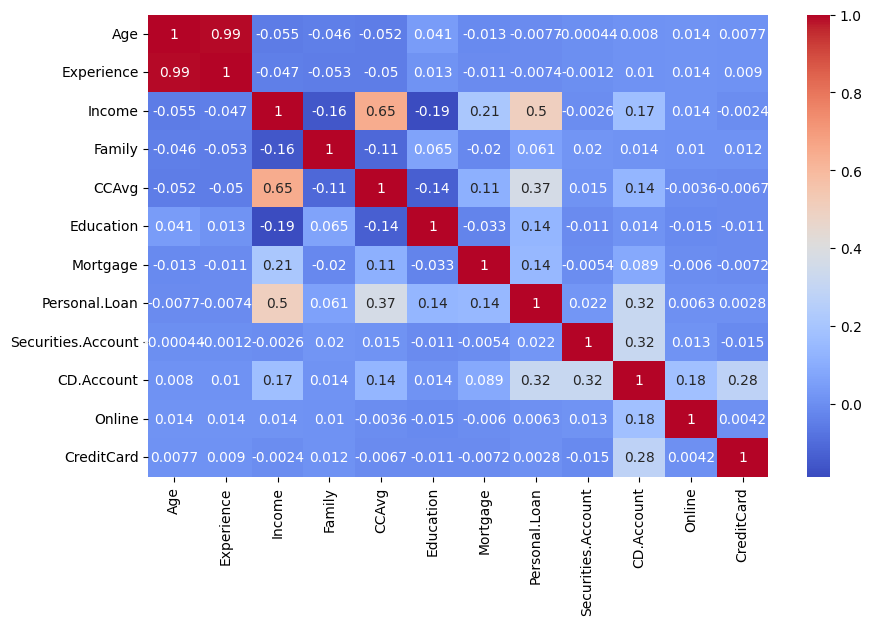

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(loan.corr(), annot=True, cmap='coolwarm')
plt.show()

**Box Plot**

<Axes: xlabel='Personal.Loan', ylabel='Income'>

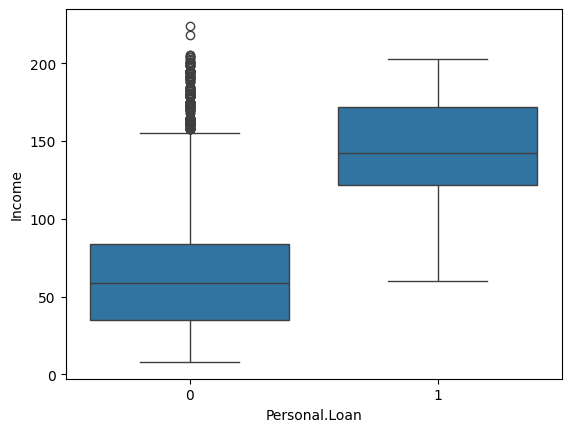

In [ ]:
sns.boxplot(x='Personal.Loan', y='Income', data=loan)

**Feature & Target Split**

In [ ]:
X=loan.drop('Personal.Loan', axis=1)
y = loan['Personal.Loan']

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

X_scaled = Scaler.fit_transform(X)

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**Linear Regression**

In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

y_pred_lin_binary = (y_pred_lin > 0.5).astype(int)

print("Linear Regression Accuracy:", accuracy_score(y_test, y_pred_lin_binary))

Linear Regression Accuracy: 0.925


**Logistic Regression**

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.954
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       895
           1       0.86      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.86      1000
weighted avg       0.95      0.95      0.95      1000



**L1 Regularization**

In [ ]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear')
l1_model.fit(X_train, y_train)

y_pred_l1 = l1_model.predict(X_test)

print("\nL1 Regularization Accuracy:", accuracy_score(y_test, y_pred_l1))
print(classification_report(y_test, y_pred_l1))


L1 Regularization Accuracy: 0.954
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       895
           1       0.86      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.86      1000
weighted avg       0.95      0.95      0.95      1000



**L2 Regularization**

In [ ]:
l2_model = LogisticRegression(penalty='l2')
l2_model.fit(X_train, y_train)

y_pred_l2 = l2_model.predict(X_test)

print("\nL2 Regularization Accuracy:", accuracy_score(y_test, y_pred_l2))
print(classification_report(y_test, y_pred_l2))


L2 Regularization Accuracy: 0.954
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       895
           1       0.86      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.86      1000
weighted avg       0.95      0.95      0.95      1000



**Model Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear", "Logistic", "L1", "L2"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lin_binary),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_l1),
        accuracy_score(y_test, y_pred_l2)
    ]
})

print("\nModel Comparison:\n", results)


Model Comparison:
       Model  Accuracy
0    Linear     0.925
1  Logistic     0.954
2        L1     0.954
3        L2     0.954
